In [ ]:
import pandas as pd
import numpy as np
import rapid_code_load_T0 as load
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
def get_stats(path, code, n_repeats=100):
    n_all = np.zeros(n_repeats)
    n_lisa = np.zeros(n_repeats)
    n_all_1kpc = np.zeros(n_repeats)

    for ii in range(n_repeats):
        df_all = pd.read_csv(path + f'repeat_{ii+1:03d}/' + f'{code}_Galaxy_AllDWDs.csv')
        df_lisa = pd.read_csv(path + f'repeat_{ii+1:03d}/' + f'{code}_Galaxy_LISA_DWDs.csv')
        ### !! this name for distance will need to change for the main branch !!
        df_all_1kpc = df_all[df_all.dist < 1.0]
        n_all[ii] = df_all.shape[0]
        n_lisa[ii] = df_lisa.shape[0]
        n_all_1kpc[ii] = df_all_1kpc.shape[0]

    return np.mean(n_all), np.std(n_all), np.mean(n_lisa), np.std(n_lisa), np.mean(n_all_1kpc), np.std(n_all_1kpc)
    
    


In [24]:
code = "COSMIC"
galaxy_repeat_path = f"~/Desktop/galaxy_repeats/{code}/"

mean_all, std_all, mean_lisa, std_lisa, mean_all_1kpc, std_all_1kpc = get_stats(galaxy_repeat_path, code, n_repeats=100)

In [25]:
print(f'mean f>1e-4 Hz: {mean_all} ± {std_all}')
print(f'mean lisa: {mean_lisa} ± {std_lisa}')
print(f'mean f>1e-4 Hz within 1kpc: {mean_all_1kpc} ± {std_all_1kpc}')

mean f>1e-4 Hz: 1057713.16 ± 962.6743137738744
mean lisa: 2164.45 ± 43.140323364573895
mean f>1e-4 Hz within 1kpc: 3056.15 ± 56.17212386940696


In [31]:
def plot_average_distributions(path, code, n_repeats=100, column_to_plot='semiMajor', bins=np.logspace(-1.3, 0.5, 50)):
    all_dists = []
    for ii in range(n_repeats):
        df_all = pd.read_csv(path + f'repeat_{ii+1:03d}/' + f'{code}_Galaxy_AllDWDs.csv')

        hist, bin_edges = np.histogram(df_all[column_to_plot], bins=bins)
        all_dists.append(hist)
    mean_dist = np.mean(all_dists, axis=0)
    std_dist = np.std(all_dists, axis=0)
    plt.figure(figsize=(10, 6))
    plt.bar(bin_edges[:-1], mean_dist, width=np.diff(bin_edges), align='edge', yerr=std_dist, alpha=0.7, label=f'{code} mean {column_to_plot}')
    plt.xscale('log')
    plt.xlabel(column_to_plot)
    plt.ylabel('Number of DWDs')
    plt.title(f'Average {column_to_plot} distribution for {code} over {n_repeats} repeats')
    plt.legend()
    plt.show()  

    return

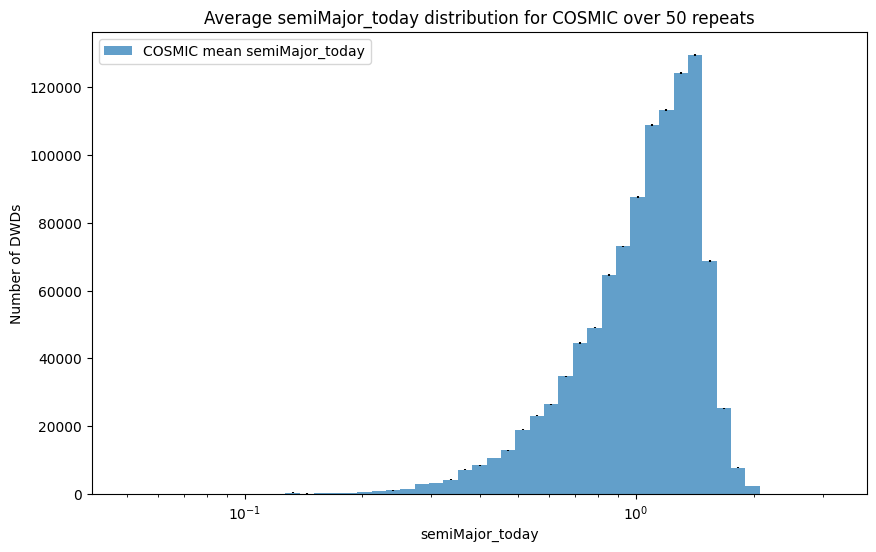

In [32]:
code = "COSMIC"
galaxy_repeat_path = f"~/Desktop/galaxy_repeats/{code}/"

_ = plot_average_distributions(galaxy_repeat_path, code, n_repeats=50, column_to_plot='semiMajor_today')

In [5]:
#sevn_gx = pd.read_csv('/Users/kbreivik/Data/Synthetic-UCBs/data_products/simulated_galaxy_populations/monte_carlo_comparisons/initial_condition_variations/fiducial/SEVN_MIST_Galaxy_AllDWDs.csv')
sevn_gx = pd.read_csv('/Users/kbreivik/Data/Synthetic-UCBs/data_products/simulated_galaxy_populations/monte_carlo_comparisons/initial_condition_variations/fiducial/SEVN_MIST_Galaxy_LISA_DWDs.csv')

In [6]:
import matplotlib.pyplot as plt

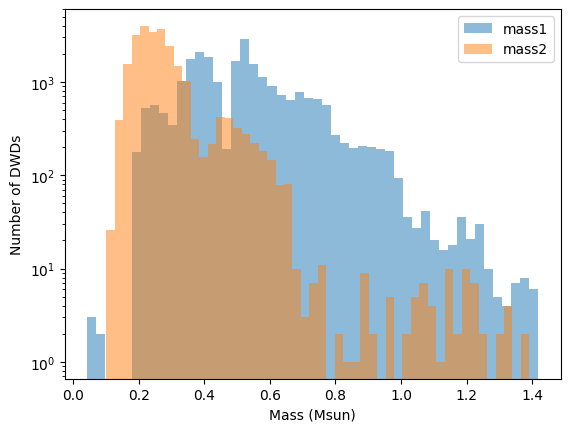

In [7]:
plt.hist(sevn_gx.mass1, bins=50, alpha=0.5, label='mass1')
plt.hist(sevn_gx.mass2, bins=50, alpha=0.5, label='mass2')
plt.xlabel('Mass (Msun)')
plt.ylabel('Number of DWDs')
plt.yscale('log')
plt.legend()
plt.show()

In [8]:
np.sort(sevn_gx.mass2), np.sort(sevn_gx.mass1)

(array([0.1011815, 0.1011815, 0.1115473, ..., 1.336399 , 1.391478 ,
        1.391478 ]),
 array([0.04292365, 0.04292365, 0.05328926, ..., 1.406582  , 1.417716  ,
        1.417716  ]))

## ok -- so there can be very low mass DWDs, but do these come from 0.7 Msun binaries?

In [13]:
sevn_T0, _ = load.load_T0_data('/Users/kbreivik/Data/Synthetic-UCBs/data_products/simulated_binary_populations/monte_carlo_comparisons/initial_condition_variations/fiducial/SEVN_MIST_T0.csv', code='SEVN_MIST', metallicity=0.02)
print(f'minimum mass 1 for SEVN: {np.min(np.sort(sevn_T0.loc[(sevn_T0.ID.isin(sevn_gx.ID)) & (sevn_T0.time == 0)].mass1))}')
print(f'minimum mass 2 for SEVN: {np.min(np.sort(sevn_T0.loc[(sevn_T0.ID.isin(sevn_gx.ID)) & (sevn_T0.time == 0)].mass2))}')

minimum mass 1 for SEVN: 0.9544291
minimum mass 2 for SEVN: 0.7032669


In [18]:
codes = ['BSE', 'COSMIC', 'SeBa', 'COMPAS', 'ComBinE', 'METISSE']
for c in codes:
    gx = pd.read_csv(f'/Users/kbreivik/Data/Synthetic-UCBs/data_products/simulated_galaxy_populations/monte_carlo_comparisons/initial_condition_variations/fiducial/{c}_Galaxy_AllDWDs.csv')
    T0, _ = load.load_T0_data(f'/Users/kbreivik/Data/Synthetic-UCBs/data_products/simulated_binary_populations/monte_carlo_comparisons/initial_condition_variations/fiducial/{c}_T0.hdf5', code=c, metallicity=0.02)
    print(f'minimum mass1 for {c}: {np.min(np.sort(T0.loc[(T0.ID.isin(gx.ID)) & (T0.time == 0)].mass1))}')
    print(f'minimum mass2 for {c}: {np.min(np.sort(T0.loc[(T0.ID.isin(gx.ID)) & (T0.time == 0)].mass2))}')
    T0_IDs = T0.loc[(T0.ID.isin(gx.ID)) & (T0.time == 0) & (T0.mass2 < 0.7)].ID
    gx_low_m2 = gx[gx.ID.isin(T0_IDs)]
    print(f'fraction of sources with ZAMS m2 < 0.7 Msun for {c}: {len(gx_low_m2)/len(gx)}')
    print()

minimum mass1 for BSE: 0.96790731
minimum mass2 for BSE: 0.66075957
fraction of sources with ZAMS m2 < 0.7 Msun for BSE: 1.4623089858887182e-06

minimum mass1 for COSMIC: 1.0046728407756929
minimum mass2 for COSMIC: 0.5795151269229097
fraction of sources with ZAMS m2 < 0.7 Msun for COSMIC: 5.899197463345091e-05

minimum mass1 for SeBa: 0.966889
minimum mass2 for SeBa: 0.960928
fraction of sources with ZAMS m2 < 0.7 Msun for SeBa: 0.0

minimum mass1 for COMPAS: 0.9437434965135001
minimum mass2 for COMPAS: 0.688487419602177
fraction of sources with ZAMS m2 < 0.7 Msun for COMPAS: 3.203150663173686e-06

minimum mass1 for ComBinE: 1.00739
minimum mass2 for ComBinE: 1.00156
fraction of sources with ZAMS m2 < 0.7 Msun for ComBinE: 0.0

minimum mass1 for METISSE: 0.9466731690312312
minimum mass2 for METISSE: 0.4607543873028932
fraction of sources with ZAMS m2 < 0.7 Msun for METISSE: 0.004637821984301385



#### I think we can argue that the population of masses below 0.7 MSun is a small fraction, even in the case for METISSE which is the maximum